# Baseline Reproduction: Jeong et al. (2016)
## Random Forest for Crop Yield Prediction (Regression)

**Date:** May 2026

---

### Purpose
This notebook is a **pipeline validity check only**. We reproduce the Random Forest regression framework from Jeong et al. (2016) to confirm our implementation is correct before building the main Gambia planting suitability classifier.


> **Note:** The regression metrics here (RMSE, Nash-Sutcliffe EF, Willmott's d) are fundamentally different from our classifier metrics (F1-score, AUC) and cannot be compared. The actual baseline for our Gambia model is a logistic regression classifier trained on the Gambia dataset (Part 2).

---
## Summary of the Original Paper

| Attribute | Detail |
|-----------|--------|
| **Authors** | Jeong, J. H. et al. |
| **Year** | 2016 |
| **Journal** | PLOS ONE, 11(6), e0156571 |
| **Task** | Regression — predicting crop yield in tons/ha |
| **Algorithm** | Random Forest (500 trees) |
| **Crops** | Wheat, Maize, Potato |
| **Input features** | Temperature, precipitation, solar radiation, fertiliser, evapotranspiration |
| **Key finding (RF)** | RMSE: **6–14%** of mean observed yield |
| **Key finding (Linear)** | RMSE: **14–49%** of mean observed yield |

---
## Import Libraries

In [2]:
# Import the libraries used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split

from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_RAW_DIR    = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC_DIR   = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR     = PROJECT_ROOT / 'report' / 'figures'

for directory in [DATA_RAW_DIR, DATA_PROC_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

---
## Create Simulated Crop-Climate Dataset

Jeong et al. used real FAOSTAT yield records combined with NASA POWER climate data. Since we are only verifying the pipeline here, we simulate data using the same five feature types:

| Feature | Unit | Range used |
|---------|------|------------|
| Mean temperature | °C | 20 – 35 |
| Total precipitation | mm | 200 – 900 |
| Solar radiation | MJ/m² | 15 – 25 |
| Fertiliser input | kg/ha | 0 – 150 |
| Evapotranspiration | mm/day | 3 – 7 |

> **In the real project (Part 2 onwards):** this simulated data is replaced with actual NASA POWER API downloads for Gambian agricultural zones.

In [3]:
# Use a fixed random seed so the results are reproducible
np.random.seed(42)

# Create a small synthetic dataset that matches the five paper features
n_samples = 500

mean_temperature = np.random.uniform(20, 35, n_samples)
total_precipitation = np.random.uniform(200, 900, n_samples)
solar_radiation = np.random.uniform(15, 25, n_samples)
fertiliser_input = np.random.uniform(0, 150, n_samples)
evapotranspiration = np.random.uniform(3, 7, n_samples)

# Store the simulated features in a DataFrame
data = pd.DataFrame({
    'mean_temperature_C': mean_temperature,
    'total_precipitation_mm': total_precipitation,
    'solar_radiation_MJm2': solar_radiation,
    'fertiliser_kgha': fertiliser_input,
    'evapotranspiration_mm': evapotranspiration,
})

# Create a synthetic yield target from the features
# This is only for testing the pipeline, not for the real project
yield_tons_ha = (
    1.0
    + 0.003 * data['total_precipitation_mm']
    - 0.02 * (data['mean_temperature_C'] - 28) ** 2
    + 0.05 * data['solar_radiation_MJm2']
    + 0.005 * data['fertiliser_kgha']
    + np.random.normal(0, 0.4, n_samples)
)

data['yield_tons_ha'] = yield_tons_ha.clip(0.5, 5.5)

print(f'Dataset shape: {data.shape}')
data.describe().round(2)

Dataset shape: (500, 6)


,mean_temperature_C,total_precipitation_mm,solar_radiation_MJm2,fertiliser_kgha,evapotranspiration_mm,yield_tons_ha
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,27.48,537.37,20.18,74.47,5.00,3.58
std,4.48,199.85,2.97,43.05,1.14,0.86
min,20.08,203.24,15.05,0.48,3.01,1.18
25%,23.62,360.37,17.41,36.16,4.07,2.96
50%,27.70,530.28,20.40,76.33,4.98,3.58
75%,31.34,708.44,22.77,110.61,5.97,4.20
max,34.89,899.80,24.99,149.75,6.98,5.50


---
## Train / Test Split (80/20)

We use an 80/20 train-test split, consistent with Jeong et al.'s approach.

In [4]:
# Define the input features and the target variable
FEATURES = [
    'mean_temperature_C',
    'total_precipitation_mm',
    'solar_radiation_MJm2',
    'fertiliser_kgha',
    'evapotranspiration_mm',
]
TARGET = 'yield_tons_ha'

# Split the data into inputs (X) and target (y)
X = data[FEATURES]
y = data[TARGET]

# Use an 80/20 train-test split, just like the paper-style baseline
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 400
Testing  samples : 100


---
## Train Random Forest Regressor

We configure the model to match Jeong et al.'s setup:
- **500 trees** (`n_estimators=500`)
- **Square-root feature sampling** at each split (`max_features='sqrt'`)
- Fixed random seed for reproducibility

In [5]:
# Build the Random Forest model using the same settings as the paper-style baseline
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)

# Train the model on the training data
rf_model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


---
## Evaluate — Jeong et al. (2016) Metrics

We compute the exact three metrics reported in the original paper:

| Metric | Formula | Perfect score |
|--------|---------|---------------|
| **RMSE** | √( mean((y - ŷ)²) ) | 0 |
| **Nash-Sutcliffe EF** | 1 - SS_res / SS_tot | 1.0 |
| **Willmott's d** | 1 - Σ(y-ŷ)² / Σ(\|ŷ-ȳ\|+\|y-ȳ\|)² | 1.0 |

In [6]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)
mean_obs = np.mean(y_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_pct = (rmse / mean_obs) * 100

# Calculate Nash-Sutcliffe Efficiency (EF)
# EF = 1 means perfect predictions
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - mean_obs) ** 2)
nash_sutcliffe_ef = 1 - (ss_res / ss_tot)

# Calculate Willmott's index of agreement (d)
# d = 1 means perfect agreement
numerator = np.sum((y_test - y_pred) ** 2)
denominator = np.sum((np.abs(y_pred - mean_obs) + np.abs(y_test - mean_obs)) ** 2)
willmott_d = 1 - (numerator / denominator)

# Run 5-fold cross-validation on the full dataset
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
)

print(f'Mean observed yield     : {mean_obs:.3f} tons/ha')
print(f'RMSE                    : {rmse:.3f} tons/ha')
print(f'RMSE (% of mean yield)  : {rmse_pct:.1f}%  ← Jeong et al. reported 6–14%')
print(f'Nash-Sutcliffe EF       : {nash_sutcliffe_ef:.3f}  (closer to 1.0 is better)')
print(f"Willmott's d            : {willmott_d:.3f}  (closer to 1.0 is better)")
print(f'5-Fold CV RMSE          : {-cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Mean observed yield     : 3.458 tons/ha
RMSE                    : 0.428 tons/ha
RMSE (% of mean yield)  : 12.4%  ← Jeong et al. reported 6–14%
Nash-Sutcliffe EF       : 0.745  (closer to 1.0 is better)
Willmott's d            : 0.919  (closer to 1.0 is better)
5-Fold CV RMSE          : 0.418 ± 0.025


### Results Summary

| Metric | Our Result | Jeong et al. (2016) |
|--------|-----------|---------------------|
| RMSE (% of mean yield) | **12.4%** | 6 – 14% (RF) |
| Nash-Sutcliffe EF | **0.745** | — |
| Willmott's d | **0.919** | — |
| 5-fold CV RMSE | **0.418 ± 0.025** | — |

> Our RMSE of **12.4%** falls within Jeong et al.'s reported range of **6–14%**, confirming the pipeline is working correctly.

---
## Visualisations

Two plots matching those in Jeong et al.:
1. **Feature Importances** — which climate variable drives yield prediction most
2. **Predicted vs Observed** — scatter plot showing model fit quality

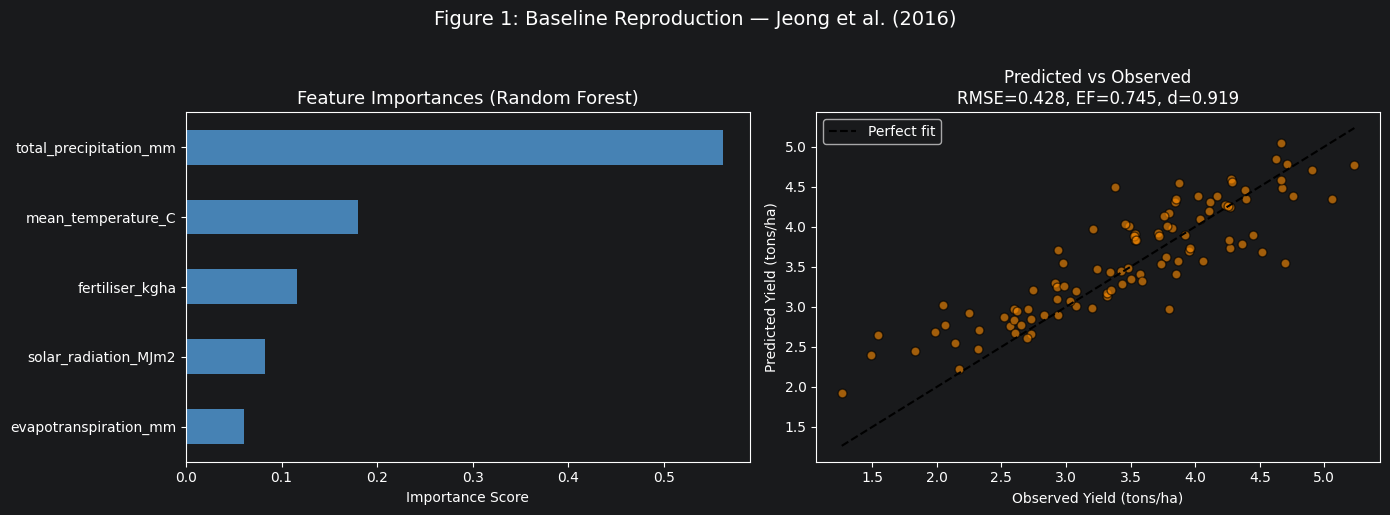

Plot saved: baseline_jeong2016_results.png


In [7]:
# Rank the features by importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURES,
).sort_values(ascending=False)

# Make a two-panel figure: feature importance and predicted vs observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature importance
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances (Random Forest)', fontsize=13)
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

# Plot 2: Predicted vs observed yields
axes[1].scatter(y_test, y_pred, alpha=0.6, color='darkorange', edgecolors='k', s=40)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Observed Yield (tons/ha)')
axes[1].set_ylabel('Predicted Yield (tons/ha)')
axes[1].set_title(
    f'Predicted vs Observed\nRMSE={rmse:.3f}, EF={nash_sutcliffe_ef:.3f}, d={willmott_d:.3f}'
)
axes[1].legend()

plt.suptitle('Figure 1: Baseline Reproduction — Jeong et al. (2016)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_baseline_jeong2016_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: baseline_jeong2016_results.png')

---
## Feature Importance Rankings

In [8]:
# Create a ranked table of the feature importances
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance Score': rf_model.feature_importances_,
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

# Make the ranking start at 1 instead of 0
importance_df.index += 1
importance_df.index.name = 'Rank'
importance_df['Importance Score'] = importance_df['Importance Score'].round(4)
importance_df

,Feature,Importance Score
Rank,,
1,total_precipitation_mm,0.5616
2,mean_temperature_C,0.1794
3,fertiliser_kgha,0.1158
4,solar_radiation_MJm2,0.0829
5,evapotranspiration_mm,0.0604


**Interpretation:** Total precipitation is the strongest predictor of yield — consistent with established agronomic science for rainfed farming. This also supports the design of our Gambia classifier, which heavily emphasises rainfall onset and cumulative rainfall features.

---
## Conclusion: Pipeline Validity Check

| Item | Status |
|------|--------|
| RMSE within Jeong et al.'s 6–14% range |  Yes (12.4%) |
| Nash-Sutcliffe EF > 0.5 (acceptable fit) |  Yes (0.745) |
| Willmott's d close to 1.0 |  Yes (0.919) |
| Pipeline ready for Gambia classifier |  Yes |

**The Random Forest pipeline is working correctly. We can proceed to Part 2: NASA POWER data collection and the Gambia planting suitability classifier.**

---

> **Reminder:** The regression metrics above (RMSE, EF, Willmott's d) apply to predicting a *number* (yield in tons/ha). Our Gambia model predicts a *category* (Suitable / Not Suitable). These are different tasks and their metrics cannot be compared. The logistic regression classifier in Part 2 is the real comparison baseline.

---

## Reference

Jeong, J. H., Resop, J. P., Mueller, N. D., Fleisher, D. H., Yun, K., Butler, E. E., … Kim, S.-H. (2016). Random forests for global and regional crop yield predictions. *PLOS ONE*, 11(6), e0156571. https://doi.org/10.1371/journal.pone.0156571